# Classifying newswires - A single label multi-class classification

Reuters dataset, a set of short newswires and their topics, published
by Reuters in 1986.

There
are 46 different topics; some topics are more represented than others, but each topic
has at least 10 examples in the training set.

### Loading and understanding the data

In [87]:
from tensorflow.keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

In [88]:
len(train_data), len(train_labels), len(test_data), len(test_labels)

(8982, 8982, 2246, 2246)

In [89]:
train_data.shape, train_labels.shape, test_data.shape, test_labels.shape

((8982,), (8982,), (2246,), (2246,))

train_data is a 1-dimensional array containing 8,982 training samples.

Each sample has variable length.

Each sample is a news article (newswire) from Reuters, encoded as a sequence of integers.

Each integer = a unique word index in the vocabulary.

The text of each news article is preprocessed and converted into a list of word IDs.

In [90]:
print(train_data[10])

[1, 245, 273, 207, 156, 53, 74, 160, 26, 14, 46, 296, 26, 39, 74, 2979, 3554, 14, 46, 4689, 4329, 86, 61, 3499, 4795, 14, 61, 451, 4329, 17, 12]


In [91]:
word_index = reuters.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()]
)

decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)

print(decoded_newswire)

? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


In [92]:
train_labels[10] # what topic it belongs to

np.int64(3)

In [95]:
print(set(train_labels)) # 46 class classification

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45)}


### Preparing the data for feeding to neural network

In [13]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results

In [97]:
len(train_data[0]), len(train_data[1]), len(train_data[2]), len(train_data[3]), len(train_data[4])

(87, 56, 139, 224, 101)

In [14]:
x_train = vectorize_sequences(train_data)

In [15]:
x_test = vectorize_sequences(test_data)

In [98]:
x_train.shape, x_test.shape

((8982, 10000), (2246, 10000))

To vectorize the labels, there are two possibilities: 

1)  you can cast the label list as an integer tensor

2)  you can use one-hot encoding.

One-hot encoding is a widely used format
for categorical data, also called categorical encoding. 

In this case, one-hot encoding of
the labels consists of embedding each label as an all-zero vector with a 1 in the place of
the label index.

In [100]:
def to_one_hot(labels, dimension=46):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1.
    
    return results

In [101]:
y_train = to_one_hot(train_labels)

In [102]:
y_test = to_one_hot(test_labels)

In [103]:
y_train.shape, y_test.shape, train_labels.shape, test_labels.shape

((8982, 46), (2246, 46), (8982,), (2246,))

In [104]:
# Use the pre-built Keras method for one-hot encoding

from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [105]:
y_train.shape, y_test.shape, train_labels.shape, test_labels.shape

((8982, 46), (2246, 46), (8982,), (2246,))

This topic-classification problem looks similar to the previous movie-review classification problem: in both cases, we’re trying to classify short snippets of text. 

But there is a new constraint here: the number of output classes has gone from 2 to 46. 

The dimensionality of the output space is much larger.

### A note on designing the layers of neural network

In a stack of Dense layers like those we’ve been using, each layer can only access
information present in the output of the previous layer.

If one layer drops some
information relevant to the classification problem, this information can never be
recovered by later layers.

In the previous example, we used 16-dimensional intermediate layers, but a
16-dimensional space may be too limited to learn to separate 46 different classes:
such small layers may act as information bottlenecks, permanently dropping rele-
vant information.

In [108]:
import keras
from keras import layers

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

Look at the output dimensions in each layer. 

First, we end the model with a Dense layer of size 46. This means for each input
sample, the network will output a 46-dimensional vector. Each entry in this vector
(each dimension) will encode a different output class.

Second, the last layer uses a softmax activation. You saw this pattern in the MNIST
example. It means the model will output a probability distribution over the 46 different
output classes—for every input sample, the model will produce a 46-dimensional out-
put vector, where output[i] is the probability that the sample belongs to class i. The
46 scores will sum to 1.

The best loss function to use in this case is categorical_crossentropy. It mea-
sures the distance between two probability distributions: here, between the probability
distribution output by the model and the true distribution of the labels. By minimiz-
ing the distance between these two distributions, you train the model to output some-
thing as close as possible to the true labels.

The importance of having sufficiently large intermediate layers :

Because the final outputs are 46-dimensional, you should
avoid intermediate layers with many fewer than 46 units so as to capture the representations.

In [111]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Train-validation-test split

In [112]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

### Train the model

In [113]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4929 - loss: 2.7520 - val_accuracy: 0.6250 - val_loss: 1.8764
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6804 - loss: 1.5580 - val_accuracy: 0.6970 - val_loss: 1.3780
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7453 - loss: 1.1709 - val_accuracy: 0.7280 - val_loss: 1.1862
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7874 - loss: 0.9561 - val_accuracy: 0.7630 - val_loss: 1.0727
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8264 - loss: 0.7947 - val_accuracy: 0.7770 - val_loss: 1.0247
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8530 - loss: 0.6684 - val_accuracy: 0.7930 - val_loss: 0.9576
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8800 - loss: 0.5683 - val_accuracy: 0.8050 - val_loss: 0.9391
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9013 - loss: 0.4795 - val_accuracy: 0.8200 - val_loss

### Evaluate the model

##### loss curve and accuracy curve

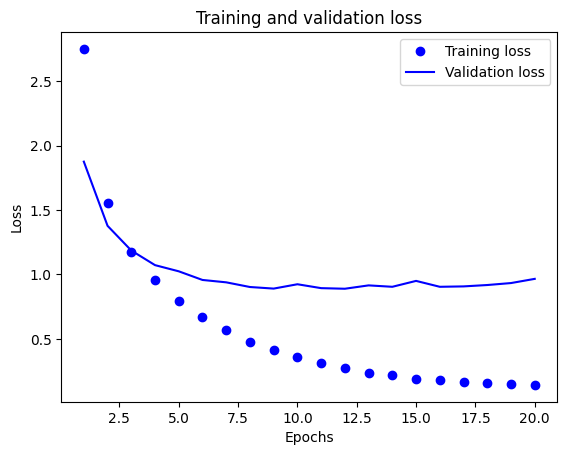

In [114]:
import matplotlib.pyplot as plt

loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

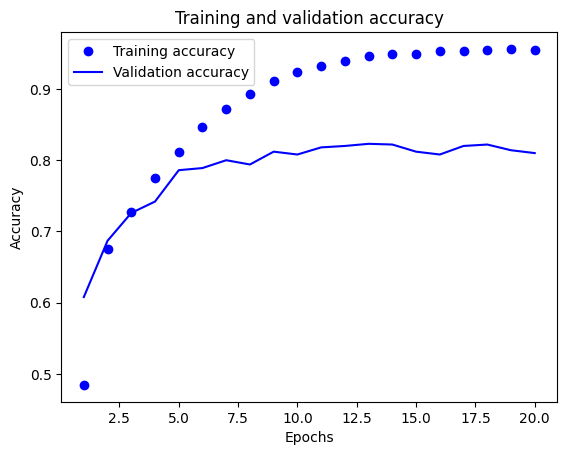

In [32]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The model begins to overfit after nine epochs. Let’s train a new model from scratch
for nine epochs and then evaluate it on the test set.

### Retraining the model with correct epochs

In [115]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

In [116]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [117]:
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512
)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5247 - loss: 2.4952
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6880 - loss: 1.4168
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7630 - loss: 1.0754
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8144 - loss: 0.8606
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8508 - loss: 0.7063
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8776 - loss: 0.5859
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8960 - loss: 0.4835
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9095 - loss: 0.4087
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9224 - loss: 0.3499


In [118]:
results = model.evaluate(x_test, y_test) # to see how test data performs

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step - accuracy: 0.7979 - loss: 0.8758


In [119]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step


In [120]:
len(predictions)

2246

In [40]:
predictions[0].shape

(46,)

In [121]:
predictions[0]

array([5.0494298e-05, 1.8863275e-04, 3.9279065e-04, 8.5244697e-01,
       1.3267505e-01, 4.1598469e-05, 1.5202307e-04, 4.5154535e-05,
       1.6817930e-03, 8.4474334e-05, 2.8650171e-05, 1.6088028e-03,
       2.4295035e-05, 2.5386264e-04, 2.4727371e-04, 1.4766900e-05,
       4.0382477e-03, 1.3424153e-04, 2.1536580e-04, 1.1679748e-03,
       7.8556780e-04, 2.0467516e-04, 2.4325222e-05, 8.4348350e-05,
       6.4058419e-05, 9.7984375e-05, 2.8963004e-06, 1.4829908e-04,
       2.2499469e-05, 3.0638814e-05, 3.4429489e-05, 6.1182212e-04,
       8.2984843e-05, 8.1038261e-06, 1.2447441e-04, 2.2658780e-06,
       9.3656461e-05, 3.5582310e-05, 2.2558661e-05, 1.8577311e-03,
       2.6787055e-05, 8.9296060e-05, 5.0736735e-06, 2.1818820e-05,
       1.7956643e-05, 7.8699131e-06], dtype=float32)

In [41]:
np.sum(predictions[0])

np.float32(0.99999994)

In [42]:
np.argmax(predictions[0])

np.int64(3)

### A different way to handle the labels and the loss

In [43]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [44]:
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Repeat the experiemnt with fewer dimensional layers

In [122]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(46, activation="softmax")
])

In [123]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val)
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3925 - loss: 3.3308 - val_accuracy: 0.4620 - val_loss: 3.0458
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3789 - loss: 2.9026 - val_accuracy: 0.2440 - val_loss: 2.7811
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2672 - loss: 2.5668 - val_accuracy: 0.2880 - val_loss: 2.4775
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3208 - loss: 2.1959 - val_accuracy: 0.3220 - val_loss: 2.1358
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4873 - loss: 1.7110 - val_accuracy: 0.6740 - val_loss: 1.5923
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7229 - loss: 1.2060 - val_accuracy: 0.6760 - val_loss: 1.3552
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7423 - loss: 1.0304 - val_accuracy: 0.6920 - val_loss: 1.3113
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7573 - loss: 0.9377 - val_accuracy: 0.6990 - val_loss:

Inferences:

The model now peaks at ~71% validation accuracy, an 8% absolute drop.

This drop is
mostly due to the fact that we’re trying to compress a lot of information (enough information to recover the separation hyperplanes of 46 classes) into an intermediate space that is too low-dimensional. 

The model is able to cram most of the necessary
information into these four-dimensional representations, but not all of it.

### Another set of experiments to try

1)  Try using larger or smaller layers: 32 units, 128 units, and so on.

2)  You used two intermediate layers before the final softmax classifier. Now try using a single intermediate layer, or three intermediate layers.

3)  Try with different optimizer or accuracy metric

### Summary

1)  If you’re trying to classify data points among N classes, your model should end
with a Dense layer of size N.

2)  In a single-label, multiclass classification problem, your model should end with
a softmax activation so that it will output a probability distribution over the N
output classes.

3) Categorical crossentropy is almost always the loss function you should use for
such problems. It minimizes the distance between the probability distributions
output by the model and the true distribution of the targets.

4) There are two ways to handle labels in multiclass classification:
<pre>
    a)  Encoding the labels via categorical encoding (also known as one-hot encoding) and 
        using categorical_crossentropy as a loss function.

    b)  Encoding the labels as integers and using the sparse_categorical_cross-
        entropy loss function.
</pre>
5)  If you need to classify data into a large number of categories, you should avoid
creating information bottlenecks in your model due to intermediate layers that
are too small.

# Scalar Regression - Boston housing dataset

In [130]:
from tensorflow.keras.datasets import boston_housing

(train_data, train_targets), (test_data, test_targets) = (boston_housing.load_data())

In [131]:
train_data.shape, train_targets.shape, test_data.shape, test_targets.shape

((404, 13), (404,), (102, 13), (102,))

### Preparing the data

In [132]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

train_data -= mean # train_data = train_data - mean
train_data /= std # train_data = train_data / std

test_data -= mean # to prevent data leakage
test_data /= std

Because so few samples are available, we’ll use a very small model with two intermedi-
ate layers, each with 64 units. 

In general, the less training data you have, the worse
overfitting will be, and using a small model is one way to mitigate overfitting.

### Build the model

In [133]:
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1) # note that there is NO activation function like sigmoid (binary class) / softmax (multi-class)
    ])
    model.compile(
        optimizer="rmsprop", 
        loss="mse", 
        metrics=["mae"]
    )
    return model

The model ends with a single unit and no activation (it will be a linear layer). This is a
typical setup for scalar regression (a regression where you’re trying to predict a single
continuous value). 

Applying an activation function would constrain the range the out-
put can take; for instance, if you applied a sigmoid activation function to the last layer,
the model could only learn to predict values between 0 and 1. Here, because the last
layer is purely linear, the model is free to learn to predict values in any range.

Note that we compile the model with the mse loss function—mean squared error, the
square of the difference between the predictions and the targets. This is a widely used
loss function for regression problems.
    
We’re also monitoring a new metric during training: mean absolute error (MAE). It’s the
absolute value of the difference between the predictions and the targets.

### Evaluate the model

Because the Boston Housing dataset is very small, a single train/validation split leaves very few samples for validation, making the validation score highly sensitive to which exact samples end up in the validation set. 

This causes high variance in the validation score, making it an unreliable indicator of real model performance. Therefore, K-fold cross-validation is preferred, as it evaluates the model across multiple splits and averages the results to obtain a stable estimate.

<img src="./images/dl_programming_6.png"/>

In [134]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []

for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[
        i * num_val_samples: (i + 1) * num_val_samples
    ]
    val_targets = train_targets[
        i * num_val_samples: (i + 1) * num_val_samples
    ]
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
        train_data[(i + 1) * num_val_samples:]],
        axis=0
    )
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
        train_targets[(i + 1) * num_val_samples:]],
        axis=0
    )
    model = build_model()
    model.fit(
        partial_train_data, partial_train_targets,
        epochs=num_epochs, batch_size=16, verbose=0
    )
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [135]:
all_scores

[1.9027668237686157, 2.3364148139953613, 2.606774091720581, 2.298050880432129]

In [136]:
np.mean(all_scores)

np.float64(2.2860016524791718)

In this case, we’re off by $2,300 on average,
which is significant considering that the prices range from $10,000 to $50,000

### Repeat the experiment with higher epochs

In [137]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 500
all_mae_histories = []

for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[
        i * num_val_samples: (i + 1) * num_val_samples
    ]
    val_targets = train_targets[
        i * num_val_samples: (i + 1) * num_val_samples
    ]
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
        train_data[(i + 1) * num_val_samples:]],
        axis=0
    )
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
        train_targets[(i + 1) * num_val_samples:]],
        axis=0
    )
    model = build_model()
    history = model.fit(
        partial_train_data, partial_train_targets,
        epochs=num_epochs, batch_size=16, verbose=0,
        validation_data=(val_data, val_targets)
    )
    
    mae_history = history.history["val_mae"]
    all_mae_histories.append(mae_history)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


In [138]:
average_mae_history = [
np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

In [140]:
print(average_mae_history)

[np.float64(19.51611089706421), np.float64(15.947667360305786), np.float64(11.716039657592773), np.float64(7.927877187728882), np.float64(5.954014182090759), np.float64(4.900639533996582), np.float64(4.238252878189087), np.float64(3.8086236119270325), np.float64(3.549435615539551), np.float64(3.3938830494880676), np.float64(3.258826732635498), np.float64(3.1096697449684143), np.float64(2.9851987957954407), np.float64(2.9052106738090515), np.float64(2.8207123279571533), np.float64(2.7891122102737427), np.float64(2.7513880133628845), np.float64(2.6827935576438904), np.float64(2.7067466378211975), np.float64(2.7112914323806763), np.float64(2.626546621322632), np.float64(2.5741724967956543), np.float64(2.5996193289756775), np.float64(2.561118721961975), np.float64(2.561102032661438), np.float64(2.5568078756332397), np.float64(2.564358174800873), np.float64(2.51598197221756), np.float64(2.529326617717743), np.float64(2.485162675380707), np.float64(2.5195497274398804), np.float64(2.509398400

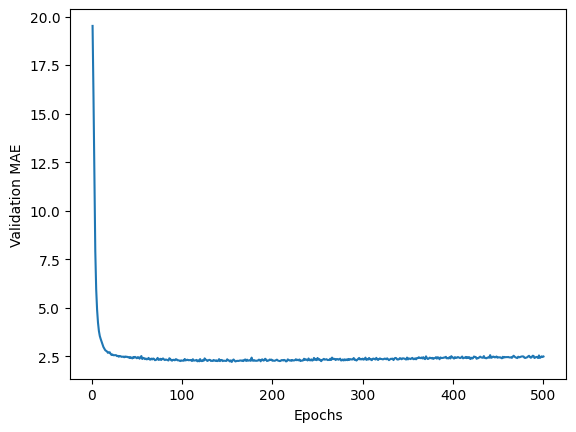

In [142]:
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [143]:
print(average_mae_history)

print(np.mean(average_mae_history))

print(np.median(average_mae_history))

[np.float64(19.51611089706421), np.float64(15.947667360305786), np.float64(11.716039657592773), np.float64(7.927877187728882), np.float64(5.954014182090759), np.float64(4.900639533996582), np.float64(4.238252878189087), np.float64(3.8086236119270325), np.float64(3.549435615539551), np.float64(3.3938830494880676), np.float64(3.258826732635498), np.float64(3.1096697449684143), np.float64(2.9851987957954407), np.float64(2.9052106738090515), np.float64(2.8207123279571533), np.float64(2.7891122102737427), np.float64(2.7513880133628845), np.float64(2.6827935576438904), np.float64(2.7067466378211975), np.float64(2.7112914323806763), np.float64(2.626546621322632), np.float64(2.5741724967956543), np.float64(2.5996193289756775), np.float64(2.561118721961975), np.float64(2.561102032661438), np.float64(2.5568078756332397), np.float64(2.564358174800873), np.float64(2.51598197221756), np.float64(2.529326617717743), np.float64(2.485162675380707), np.float64(2.5195497274398804), np.float64(2.509398400

The MAE in the first few epochs is very large because the model doesn’t know anything yet. 

Including those large values forces the plot scale to expand, making it harder to observe the meaningful variations that happen later. 

By skipping the first 10 data points, we can zoom in on the useful part of the curve and visualize the learning progress more clearly

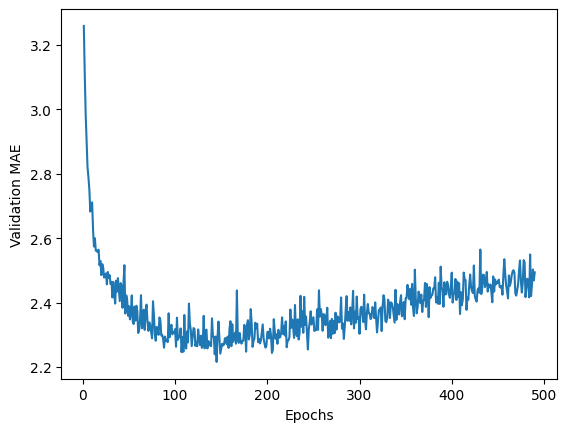

In [144]:
truncated_mae_history = average_mae_history[10:]
plt.plot(range(1, len(truncated_mae_history) + 1), truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

### Retrain the model

In [148]:
model = build_model()

model.fit(
    train_data, train_targets,
    epochs=130, batch_size=16, verbose=0
)

test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.1513 - mae: 2.5894


Neural network is not a deterministic model

In [74]:
test_mae_score

2.3932180404663086

Yes. model.evaluate(test_data, test_targets) returns the average score over the entire test dataset.

The MAE changes each run because neural networks start from random initial weights and use stochastic mini-batch training. The randomness causes different learning paths and different final models, even with the same dataset.

Sources of randomness:

1) Random weight initialization

2) Randomness in batch

3) Different gradients

With a small dataset (Boston Housing = 506 samples), these effects are more noticeable.

You can make it deterministic by setting the following parameter:

tf.random.set_seed(42)


# Save the best model

In [149]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Save the best model based on lowest validation loss
checkpoint_cb = ModelCheckpoint(
    filepath="best_model.keras",  # name of saved model file
    save_best_only=True,          # only save model if metric improves
    monitor="val_loss",           # metric to monitor
    mode="min"                    # lower val_loss is better
)

history = model.fit(
    train_data, train_targets,
    validation_data=(val_data, val_targets),
    epochs=130,
    batch_size=16,
    callbacks=[checkpoint_cb],
    verbose=0
)

Every epoch, Keras checks val_loss.

If the val_loss decreases, the model is saved to "best_model.keras".

If later epochs get worse, it doesn’t overwrite the best one.

Why save_best_only=True matters

Without it, Keras would overwrite the model at every epoch, even if performance got worse.


With it, your disk will contain only one model — the best one so far.


In [150]:
from tensorflow.keras.models import load_model

best_model = load_model("best_model.keras")
test_mse_score, test_mae_score = best_model.evaluate(test_data, test_targets)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.8732 - mae: 2.4479
